In [39]:
# If not running the full notebook linearly, run this block to import all dependencies and functions
import pandas as pd
from plotting.python_plots import plot_points, plot_aggregate_heatmap, plot_count_histogram, plot_count_vs_frac

# Data Demonstration

This notebook accompanies our pre-print [[1]](#ref1). 

In this notebook, we walk through some of the features included in this repository. We showcase the sample dataset, a subset of the full dataset publicly available at: [[2]](#ref2) and plot some relevant summary statistics. This subset consists of $120$ snapshots with a majority of pedestrians at the top of the platform, and is evenly split among the three occupancy levels described in [[1]](#ref1): low $(\leq 30$ pedestrians $)$, medium $(31-60)$, and high $(>60)$. While we import the data including passing pedestrians (useful for some plots, this data also contains velocity data), we filter these out for inference.

### References
<a id="ref1"></a>[1] L. Sickert Karam, R. M. Castro, M. Schoukens, and A. Corbetta, "Modeling inhomogeneous spatial point configurations with applications to replicated patterns in waiting crowds," arXiv preprint [arXiv:2606.14532](https://arxiv.org/abs/2606.14532) [physics.soc-ph], 2026.

<a id="ref2"></a>[2] L. Sickert Karam, R. M. Castro, M. Schoukens, and A. Corbetta, "Modeling inhomogeneous spatial point configurations with applications to replicated patterns in real-life waiting crowds - dataset: snapshots of pedestrians at Eindhoven train station," Dataset.(https://doi.org/10.5281/zenodo.23060582), 2026.

In [40]:
import pandas as pd

data_wwalking = pd.read_parquet("data/snapshots_wwalking.parquet")
data = data_wwalking.query("stand_or_walk == 0").reset_index(drop=True) # waiting peds are flagged as 0, passing peds are flagged as 1
data.drop(columns=['x_vel_SG', 'y_vel_SG', 'stand_or_walk'], inplace=True)
snapshots = [data.groupby("time_ms").get_group(t) for t in data["time_ms"].unique()]

print(data_wwalking.columns)
print(data.columns)

Index(['time_ms', 'object_identifier', 'x_position_mm', 'y_position_mm',
       'x_vel_SG', 'y_vel_SG', 'stand_or_walk', 'frac_standing', 'occupancy'],
      dtype='object')
Index(['time_ms', 'object_identifier', 'x_position_mm', 'y_position_mm',
       'frac_standing', 'occupancy'],
      dtype='object')


The snapshot data is accessed as a `pandas` dataframe. The column `time_ms` denotes the timestamp of each snapshot, thereby serving as a unique identifier. Each pedestrian is given a unique tag in column `object_identifier`, and its position is given in millimeters in `x_position_mm` and `y_position_mm`. In addition, `occupancy` denotes the number of pedestrians present in the snapshot (in `snapshots.parquet` this only counts waiting pedestrians, while in `snapshots_wwalking.parquet` all pedestrians are counted). We can easily plot snapshots using the `plot_points` function.

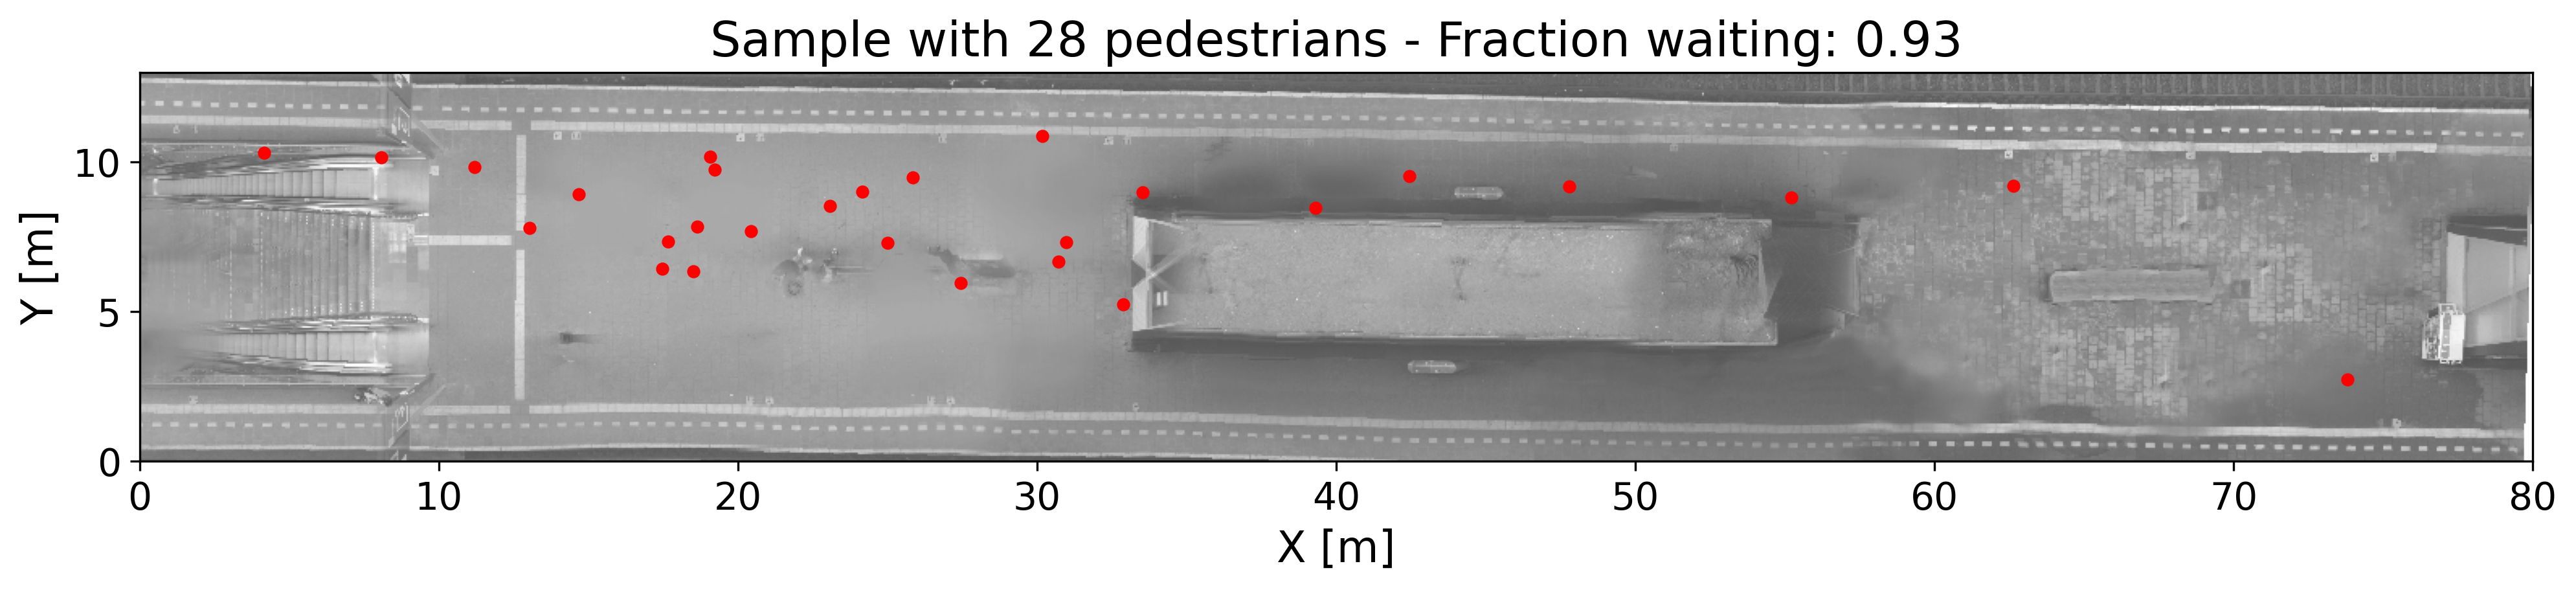

In [41]:
from plotting.python_plots import plot_points

plot_points(
    snapshots[20],
    background=True,
    frac_standing=True,
    title=True
)

We can also plot passing pedestrians, as well as their direction of movement.

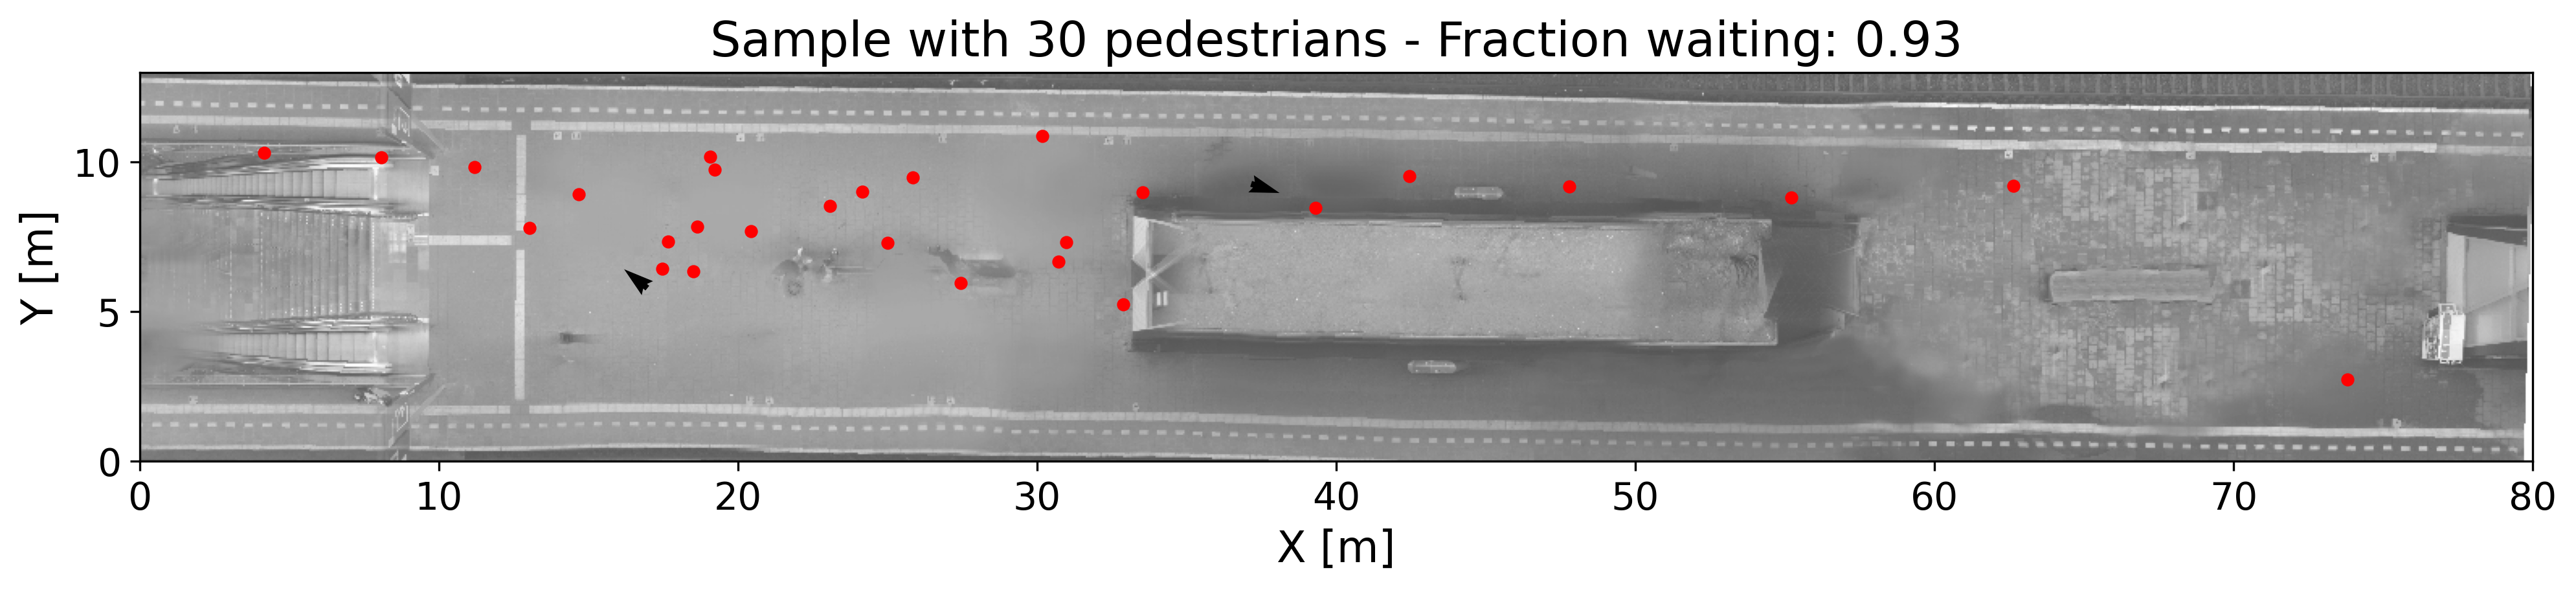

In [42]:
snapshots_wwalking = [data_wwalking.groupby("time_ms").get_group(t) for t in data_wwalking["time_ms"].unique()]

plot_points(
    snapshots_wwalking[20],
    background=True,
    frac_standing=True,
    title=True,
    with_walking=True,
    velocity=True,
    arrow_fixed_length=True
)

Next, we can get an idea of the spatial preference by plotting a heatmap of the positional data using `plot_aggregate_heatmap`. This uses a Gaussian kernel density estimator (KDE) to approximate a one-particle marginal probability distribution function. For this demonstration, we specify a bandwidth of $500$ mm, i.e. $0.5$ m.

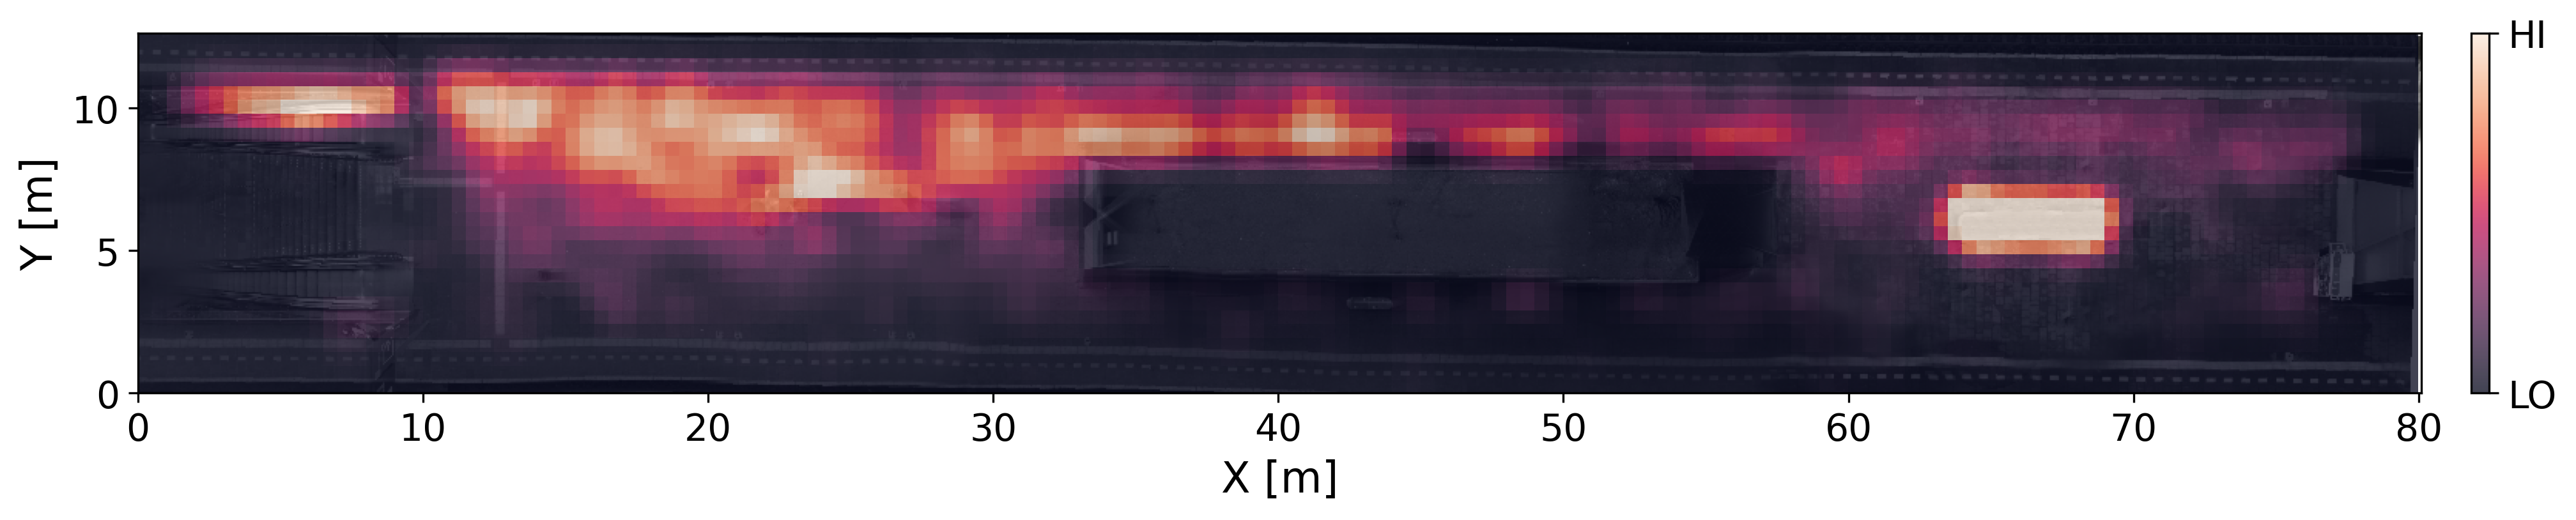

In [43]:
from plotting.python_plots import plot_aggregate_heatmap

# first, we load a grid spaced at 500mm. We will evaluate the KDE at these grid points for plotting the heatmap
grid = pd.read_parquet("data/grid_500mm.parquet")

plot_aggregate_heatmap(
    snapshots,
    grid=grid,
    bandwidth=500,
    normalize=True, # uses 99th percentile of heatmap values for better visualization
)

We can get an idea of the distribution of snapshot sizes by plotting a histogram and some summary statistics using `plot_count_histogram`

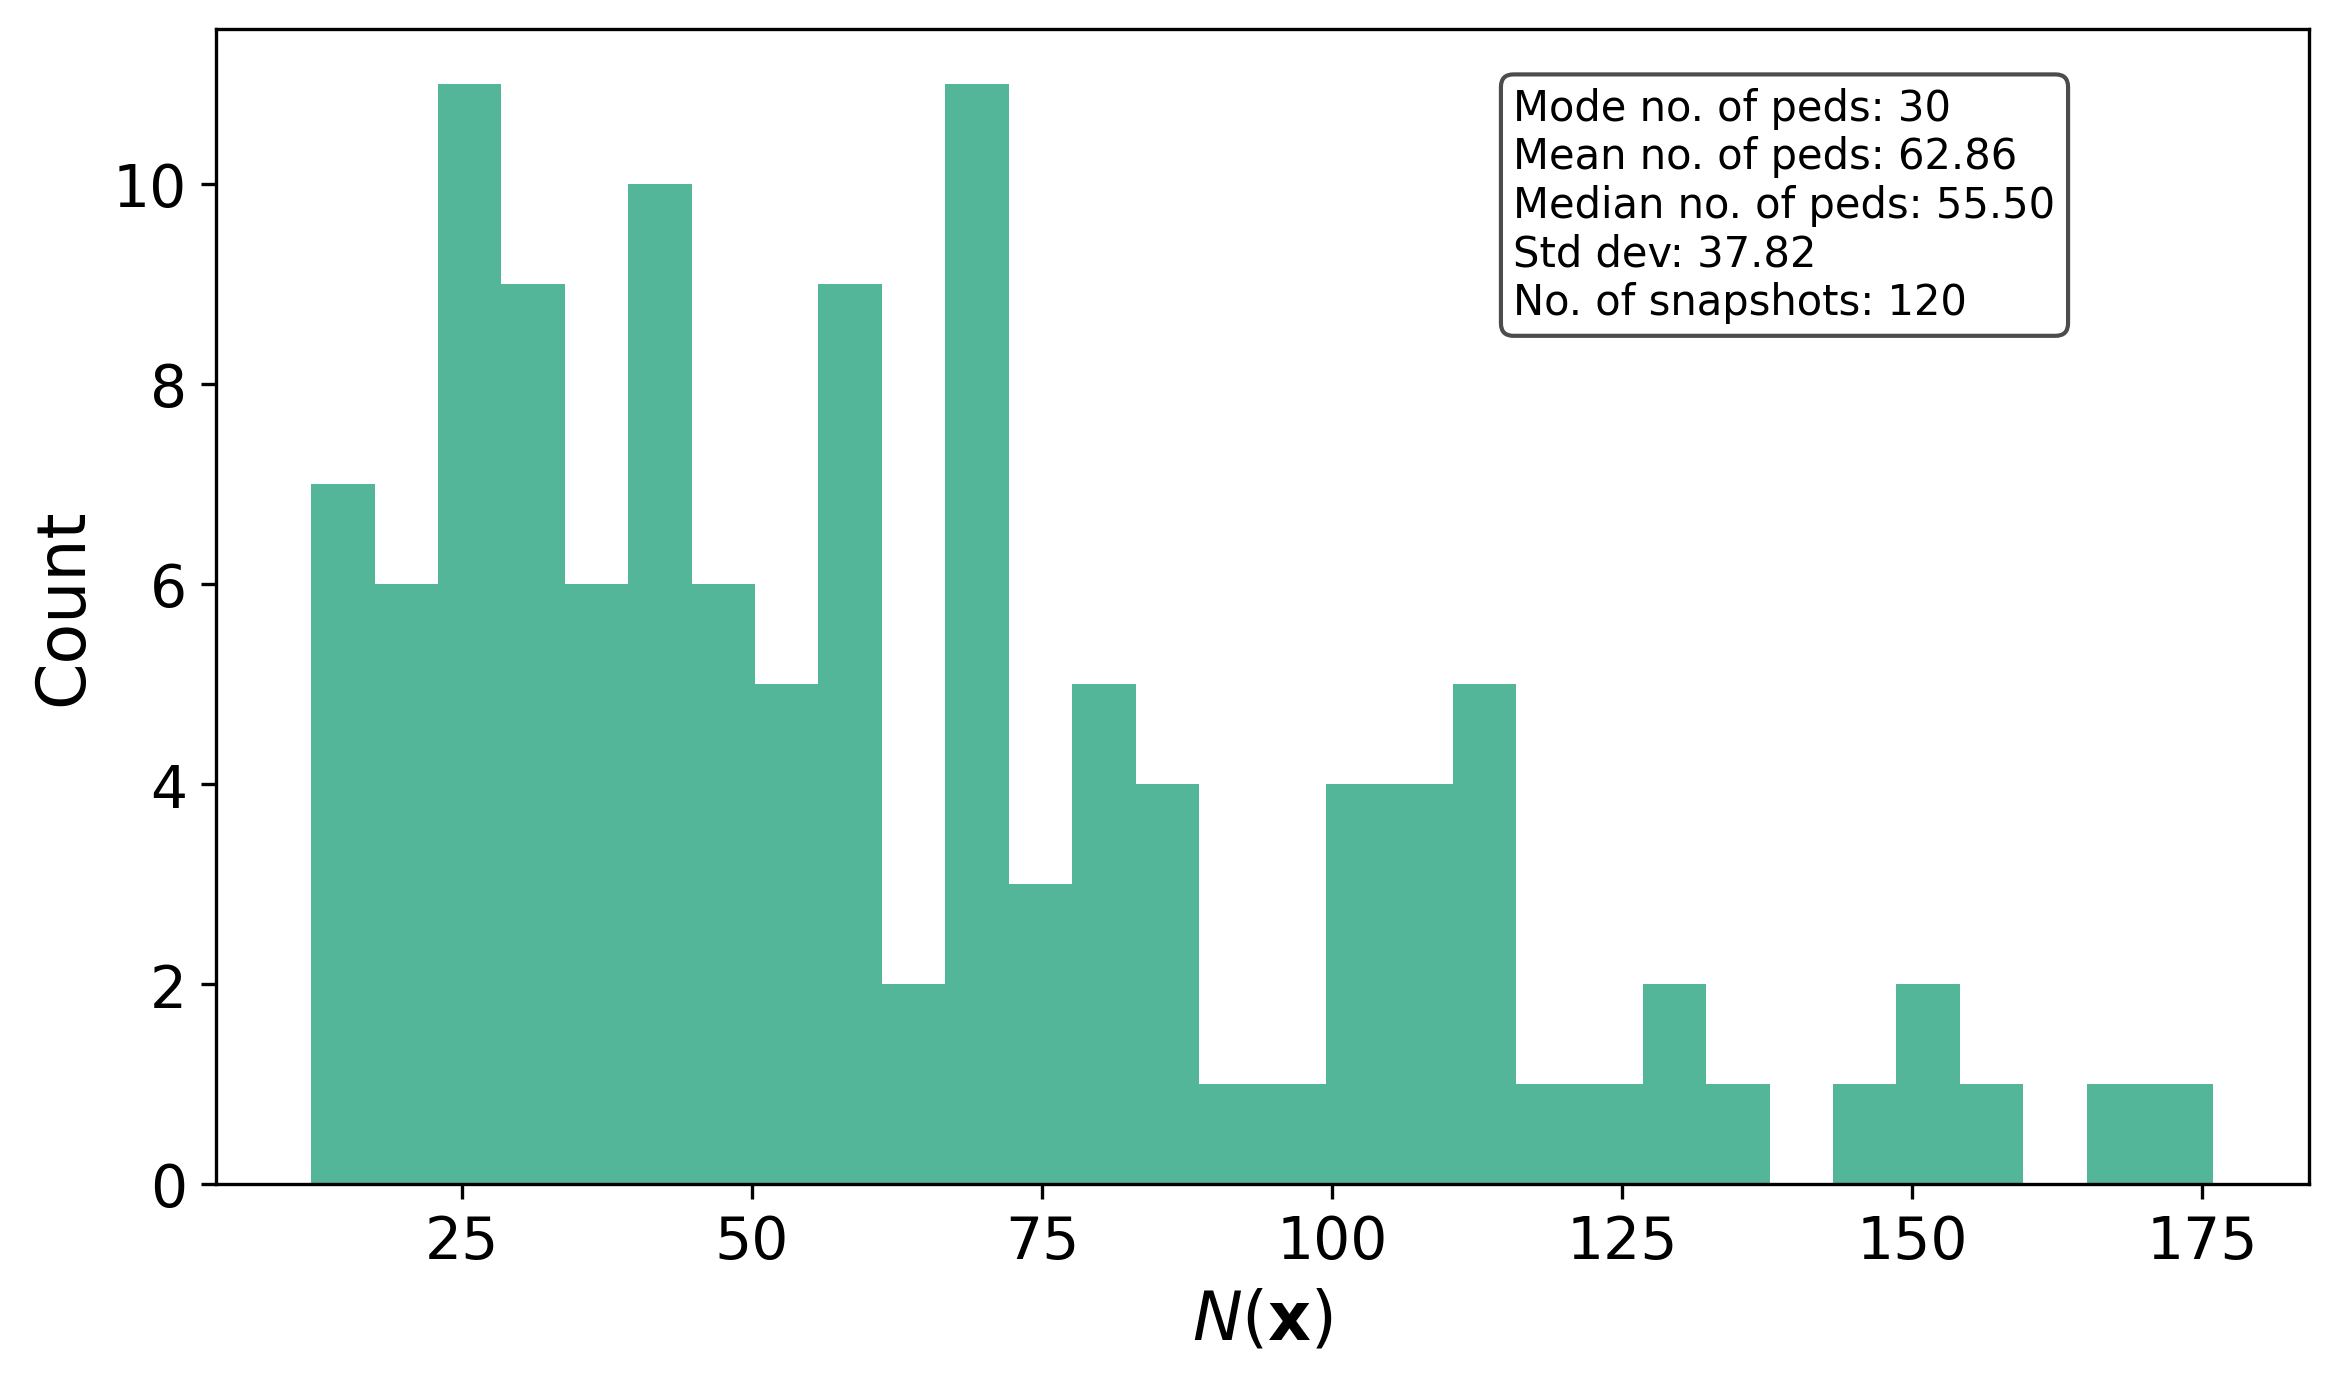

In [44]:
from plotting.python_plots import plot_count_histogram

plot_count_histogram(
    data,
    bins=30,
    add_stats=True
)

Additionally, we can visualize the relationship between the number of pedestrians in the snapshot and the fraction of those pedestrians that are waiting using `plot_count_vs_frac`. For small datasets such as this one, passing `"scatter"` to the `style` kwarg yields a clearer picture than the default `"hexbin"`.

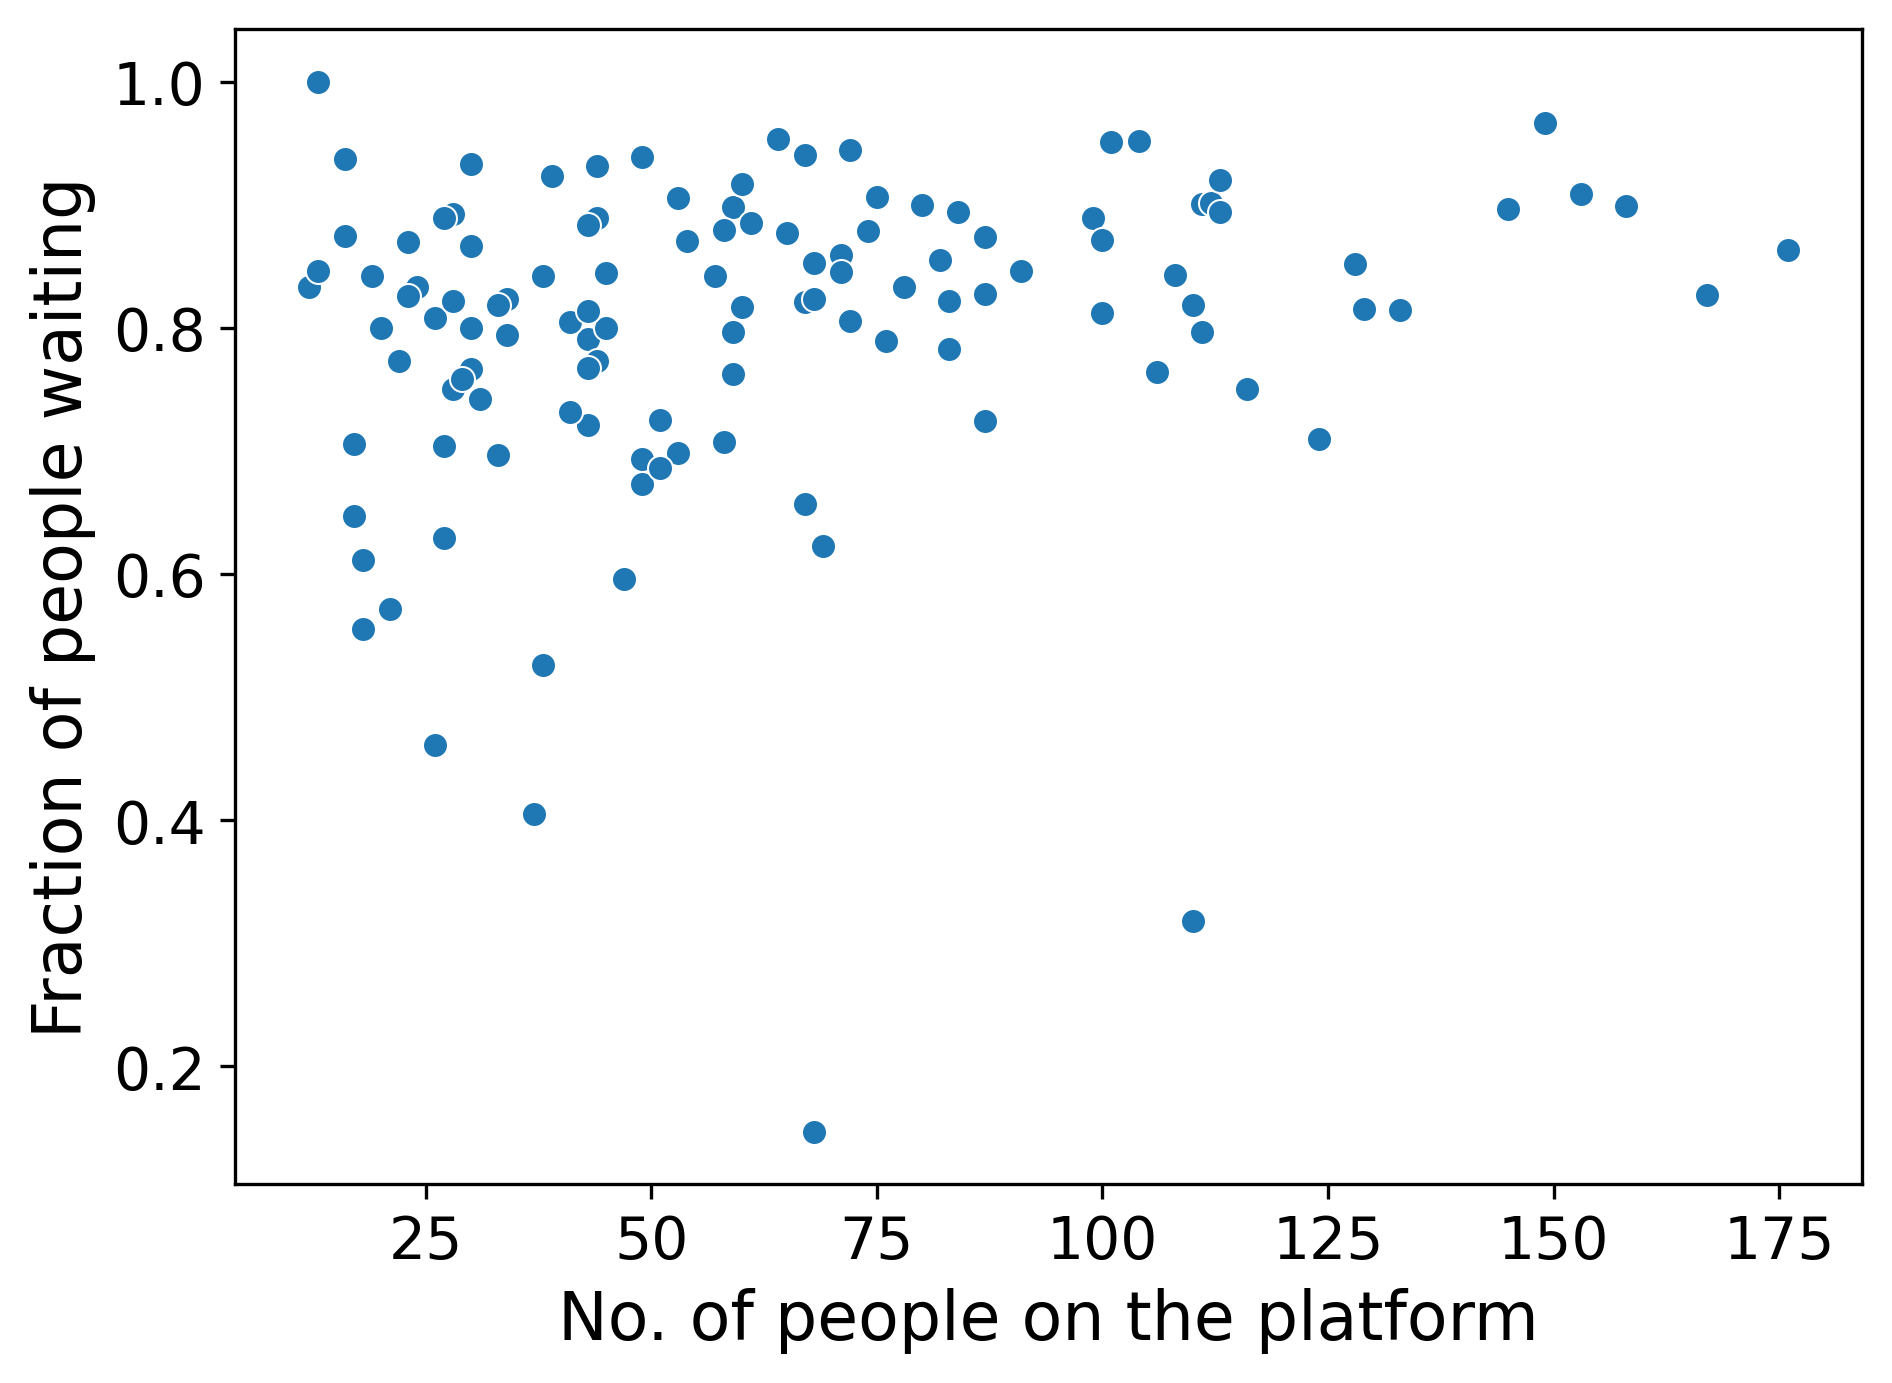

In [45]:
from plotting.python_plots import plot_count_vs_frac

plot_count_vs_frac(
    data_wwalking,
    style = "scatter"
)